# 01 — Exploratory Data Analysis
**PIX Fraud Intelligence | IBM Portfolio Project**

Dataset: [PIX Fraud BR](https://huggingface.co/datasets/andremessina/pix-fraud-br) — 2M synthetic PIX transactions  
Purpose-built dataset with BCB-aligned modalities and Febraban fraud patterns.

**Goals:**
- Understand class imbalance (fraud rate ~0.77%)
- Explore feature distributions across fraud and legitimate transactions
- Identify key discriminative features: `razao_saldo_residual`, `saldo_anterior_recebedor`
- Generate visualizations for the README

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

os.makedirs('../assets', exist_ok=True)
os.makedirs('../data/raw', exist_ok=True)

## 1. Load Dataset from Hugging Face

In [2]:
from datasets import load_dataset

print("Loading PIX Fraud BR from Hugging Face...")
ds = load_dataset("andremessina/pix-fraud-br", split="train")
df_full = ds.to_pandas()

print(f"Full dataset: {df_full.shape}")
print(f"Fraud rate:   {df_full['fraude'].mean():.4%}")
df_full.head(3)

Loading PIX Fraud BR from Hugging Face...


Full dataset: (2000000, 17)
Fraud rate:   0.7688%


,id_pagador,id_recebedor,tipo_transacao,valor_brl,saldo_anterior_pagador,saldo_posterior_pagador,saldo_anterior_recebedor,saldo_posterior_recebedor,datetime_brasilia,hora_dia,dia_semana,dia_util,horario_noturno,acima_limite_noturno,razao_saldo_residual,proporcao_valor_recebedor,fraude
0,***.754.995-**,***.387.356-**,chave_pix,43246.97,2990786.75,2947539.78,116512.41,159759.38,2024-01-06 16:00:00,17,segunda-feira,True,False,False,0.985540,0.270701,0
1,***.115.340-**,***.992.358-**,dados_bancarios,1759505.30,11329590.96,9570085.66,18450.23,1777955.53,2024-01-08 10:00:00,11,quarta-feira,True,False,False,0.844698,0.989623,0
2,***.155.883-**,***.440.282-**,chave_pix,573981.90,2678202.47,2104220.57,15633.50,589615.40,2024-01-08 21:00:00,21,segunda-feira,True,True,True,0.785684,0.973485,0


In [3]:
# Sample 100k rows for DB2 Lite (200MB limit)
# Weighted to keep all fraud cases represented
df = df_full.sample(n=100_000, random_state=42,
                    weights=df_full['fraude'].map({0: 1, 1: 50}))
df = df.reset_index(drop=True)

print(f"Sampled: {df.shape}")
print(f"Fraud rate: {df['fraude'].mean():.4%}")

Sampled: (100000, 17)


Fraud rate: 13.7350%


## 2. Class Distribution

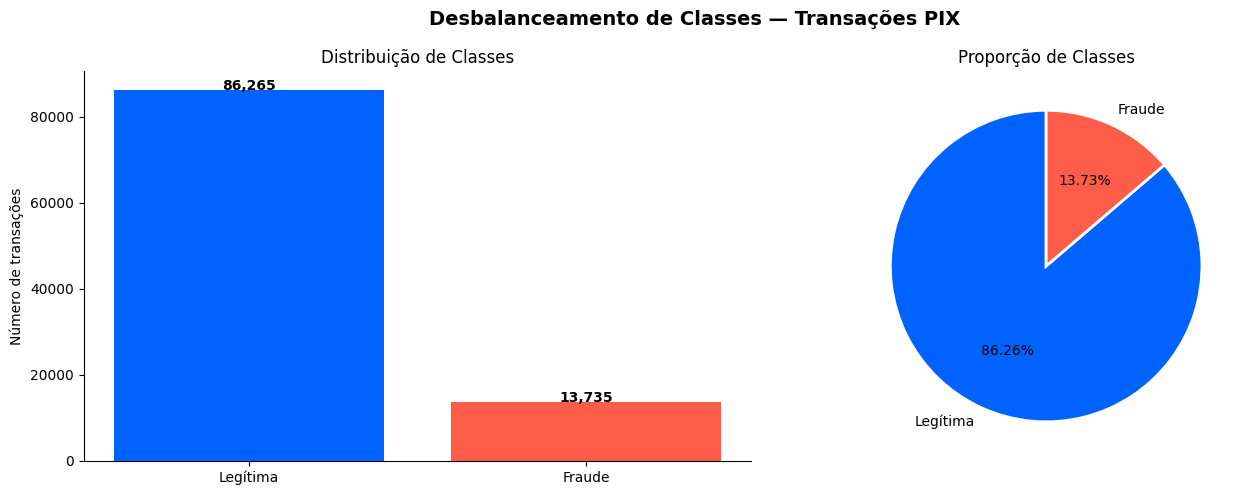

In [4]:
import os
os.makedirs('../assets', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['fraude'].value_counts()
axes[0].bar(['Legítima', 'Fraude'], counts.values, color=['#0062ff', '#ff5c49'])
axes[0].set_title('Distribuição de Classes')
axes[0].set_ylabel('Número de transações')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Legítima', 'Fraude'],
            autopct='%1.2f%%', colors=['#0062ff', '#ff5c49'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção de Classes')

plt.suptitle('Desbalanceamento de Classes — Transações PIX', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Valor da Transação + Fraude por Hora

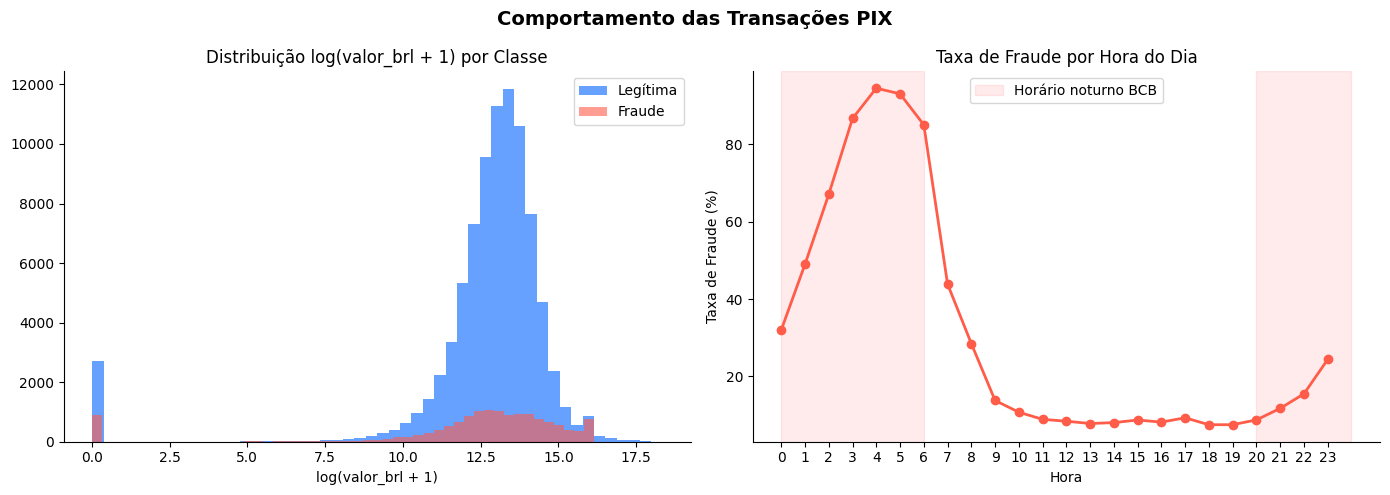

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, '#0062ff', 'Legítima'), (1, '#ff5c49', 'Fraude')]:
    axes[0].hist(np.log1p(df[df['fraude'] == label]['valor_brl']),
                 bins=50, alpha=0.6, color=color, label=name)
axes[0].set_title('Distribuição log(valor_brl + 1) por Classe')
axes[0].set_xlabel('log(valor_brl + 1)')
axes[0].legend()

fraud_by_hour = df.groupby('hora_dia')['fraude'].mean().reset_index()
axes[1].plot(fraud_by_hour['hora_dia'], fraud_by_hour['fraude'] * 100,
             marker='o', color='#ff5c49', linewidth=2)
axes[1].axvspan(20, 24, alpha=0.08, color='red', label='Horário noturno BCB')
axes[1].axvspan(0, 6, alpha=0.08, color='red')
axes[1].set_title('Taxa de Fraude por Hora do Dia')
axes[1].set_xlabel('Hora'); axes[1].set_ylabel('Taxa de Fraude (%)')
axes[1].set_xticks(range(0, 24)); axes[1].legend()

plt.suptitle('Comportamento das Transações PIX', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/amount_time_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Features Discriminativas — Separação por Classe

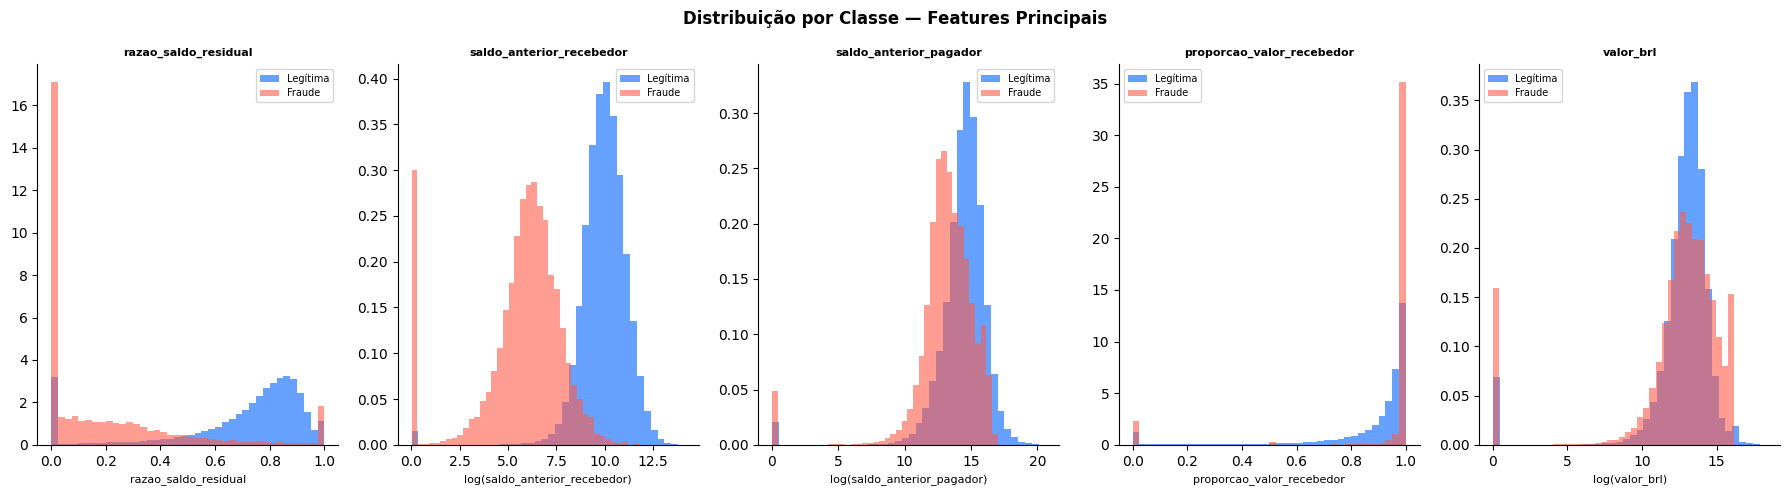

In [6]:
NUMERIC_FEATURES = [
    'razao_saldo_residual', 'saldo_anterior_recebedor',
    'saldo_anterior_pagador', 'proporcao_valor_recebedor', 'valor_brl',
]

fig, axes = plt.subplots(1, len(NUMERIC_FEATURES), figsize=(18, 5))
for ax, feat in zip(axes, NUMERIC_FEATURES):
    for label, color, name in [(0, '#0062ff', 'Legítima'), (1, '#ff5c49', 'Fraude')]:
        data = df[df['fraude'] == label][feat]
        data = np.log1p(data) if feat not in ['razao_saldo_residual', 'proporcao_valor_recebedor'] else data
        ax.hist(data, bins=40, alpha=0.6, color=color, label=name, density=True)
    xlabel = f'log({feat})' if feat not in ['razao_saldo_residual', 'proporcao_valor_recebedor'] else feat
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_title(feat, fontsize=8, fontweight='bold')
    ax.legend(fontsize=7)

plt.suptitle('Distribuição por Classe — Features Principais', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Modalidade PIX e Taxa de Fraude

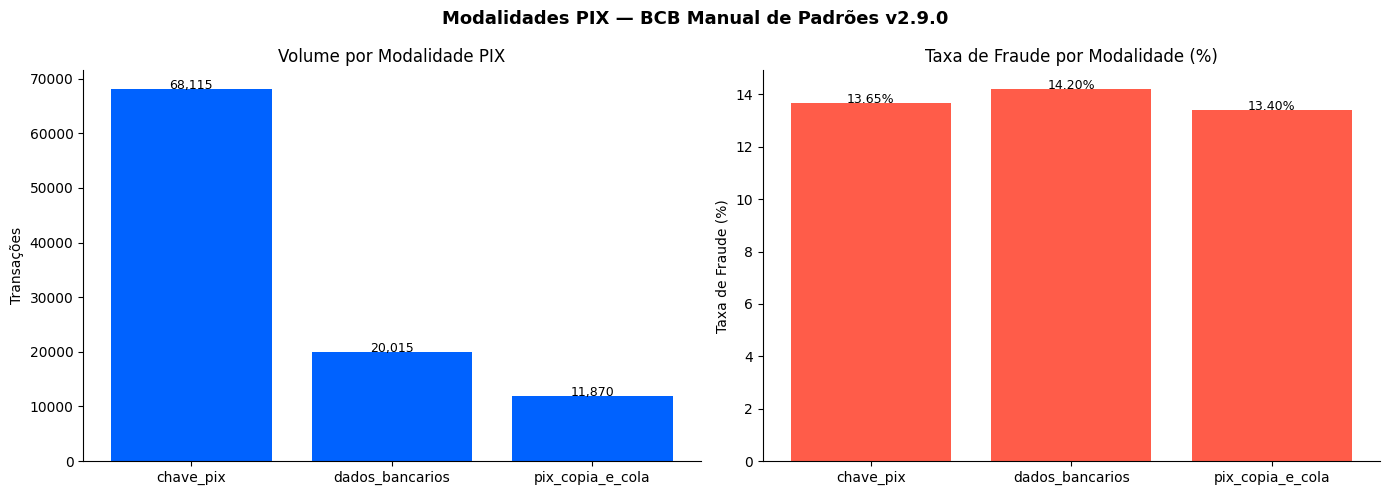

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tipo_counts = df['tipo_transacao'].value_counts()
axes[0].bar(tipo_counts.index, tipo_counts.values, color='#0062ff')
axes[0].set_title('Volume por Modalidade PIX')
axes[0].set_ylabel('Transações')
for i, v in enumerate(tipo_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

fraud_by_tipo = df.groupby('tipo_transacao')['fraude'].mean() * 100
axes[1].bar(fraud_by_tipo.index, fraud_by_tipo.values, color='#ff5c49')
axes[1].set_title('Taxa de Fraude por Modalidade (%)')
axes[1].set_ylabel('Taxa de Fraude (%)')
for i, v in enumerate(fraud_by_tipo.values):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('Modalidades PIX — BCB Manual de Padrões v2.9.0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/modalities_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

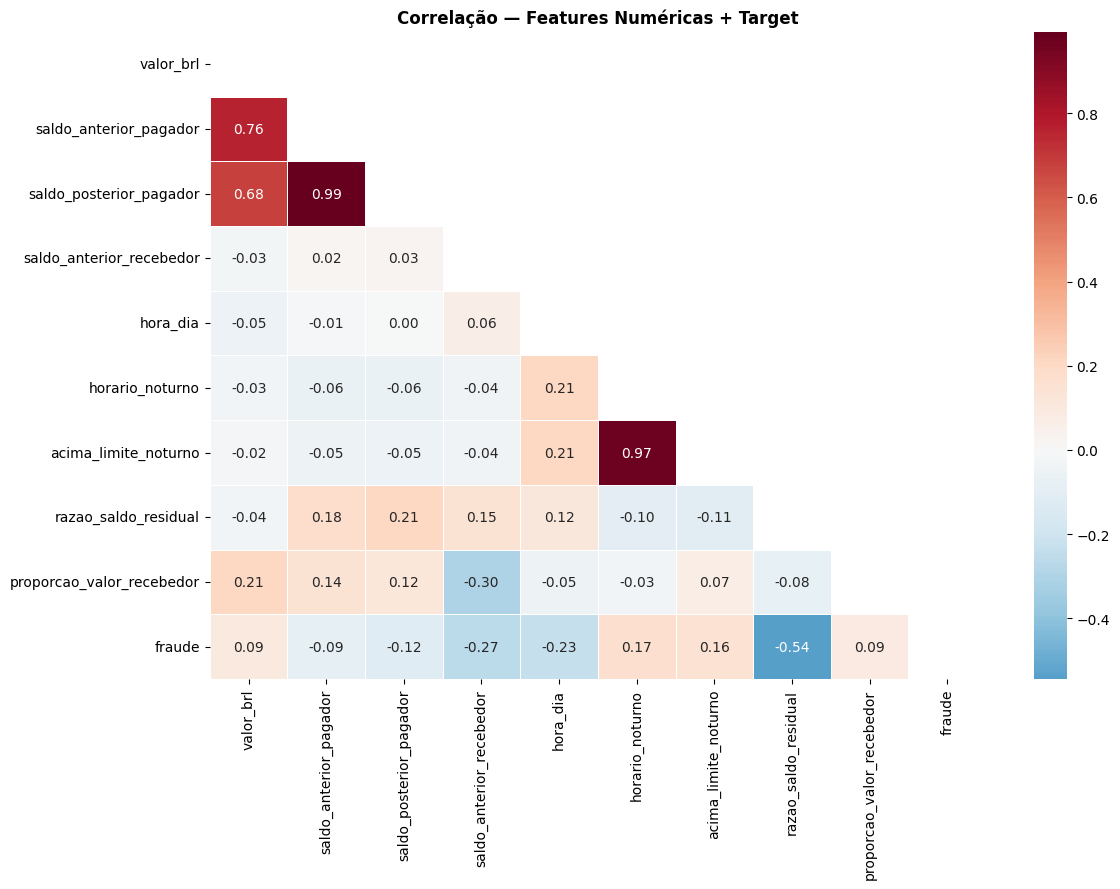

In [8]:
CORR_FEATURES = [
    'valor_brl', 'saldo_anterior_pagador', 'saldo_posterior_pagador',
    'saldo_anterior_recebedor', 'hora_dia', 'horario_noturno',
    'acima_limite_noturno', 'razao_saldo_residual',
    'proporcao_valor_recebedor', 'fraude',
]

corr = df[CORR_FEATURES].astype(float).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlação — Features Numéricas + Target', fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Sampled Dataset

In [9]:
os.makedirs('../data/raw', exist_ok=True)
df.to_parquet('../data/raw/transactions_sampled.parquet', index=False)
print(f"Saved {len(df):,} rows to data/raw/transactions_sampled.parquet")
print(f"Columns: {list(df.columns)}")
print(f"\nSummary:")
print(df.describe().round(2))

Saved 100,000 rows to data/raw/transactions_sampled.parquet
Columns: ['id_pagador', 'id_recebedor', 'tipo_transacao', 'valor_brl', 'saldo_anterior_pagador', 'saldo_posterior_pagador', 'saldo_anterior_recebedor', 'saldo_posterior_recebedor', 'datetime_brasilia', 'hora_dia', 'dia_semana', 'dia_util', 'horario_noturno', 'acima_limite_noturno', 'razao_saldo_residual', 'proporcao_valor_recebedor', 'fraude']

Summary:
         valor_brl  saldo_anterior_pagador  saldo_posterior_pagador  \
count    100000.00            1.000000e+05             1.000000e+05   
mean     995961.30            4.576950e+06             3.580988e+06   
std     2011040.40            1.254319e+07             1.109169e+07   
min           0.01            1.000000e-02             0.000000e+00   
25%      211295.39            7.026947e+05             2.916818e+05   
50%      492558.36            1.939008e+06             1.298989e+06   
75%     1023700.24            4.558756e+06             3.398395e+06   
max    92519974.